freqs_Hz.npy                    shape=(120,)                dtype=float64
  lsts_rad.npy                    shape=(203,)                dtype=float64
  mask_indices.npy                shape=(2, 61)               dtype=int64
  nm_list.npy                     shape=(61, 2)               dtype=int64
  vis_corrupted.npy               shape=(203, 120)            dtype=complex128
  vis_eor.npy                     shape=(203, 120)            dtype=complex128
  vis_fg.npy                      shape=(203, 120)            dtype=complex128
  vis_fg_eor.npy                  shape=(203, 120)            dtype=complex128

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_dir = '/nvme2/scratch/sohini/hydra-pspec-systematic/res/hera_val_npy'

# Load the data
freqs_Hz = np.load(f'{data_dir}/freqs_Hz.npy')
lsts_rad = np.load(f'{data_dir}/lsts_rad.npy')
mask_ind = np.load(f'{data_dir}/mask_indices.npy')
nm_list = np.load(f'{data_dir}/nm_list.npy')
vis_corr = np.load(f'{data_dir}/vis_corrupted.npy')
vis_eor = np.load(f'{data_dir}/vis_eor.npy')
vis_fg = np.load(f'{data_dir}/vis_fg.npy')
vis_fg_eor = np.load(f'{data_dir}/vis_fg_eor.npy')

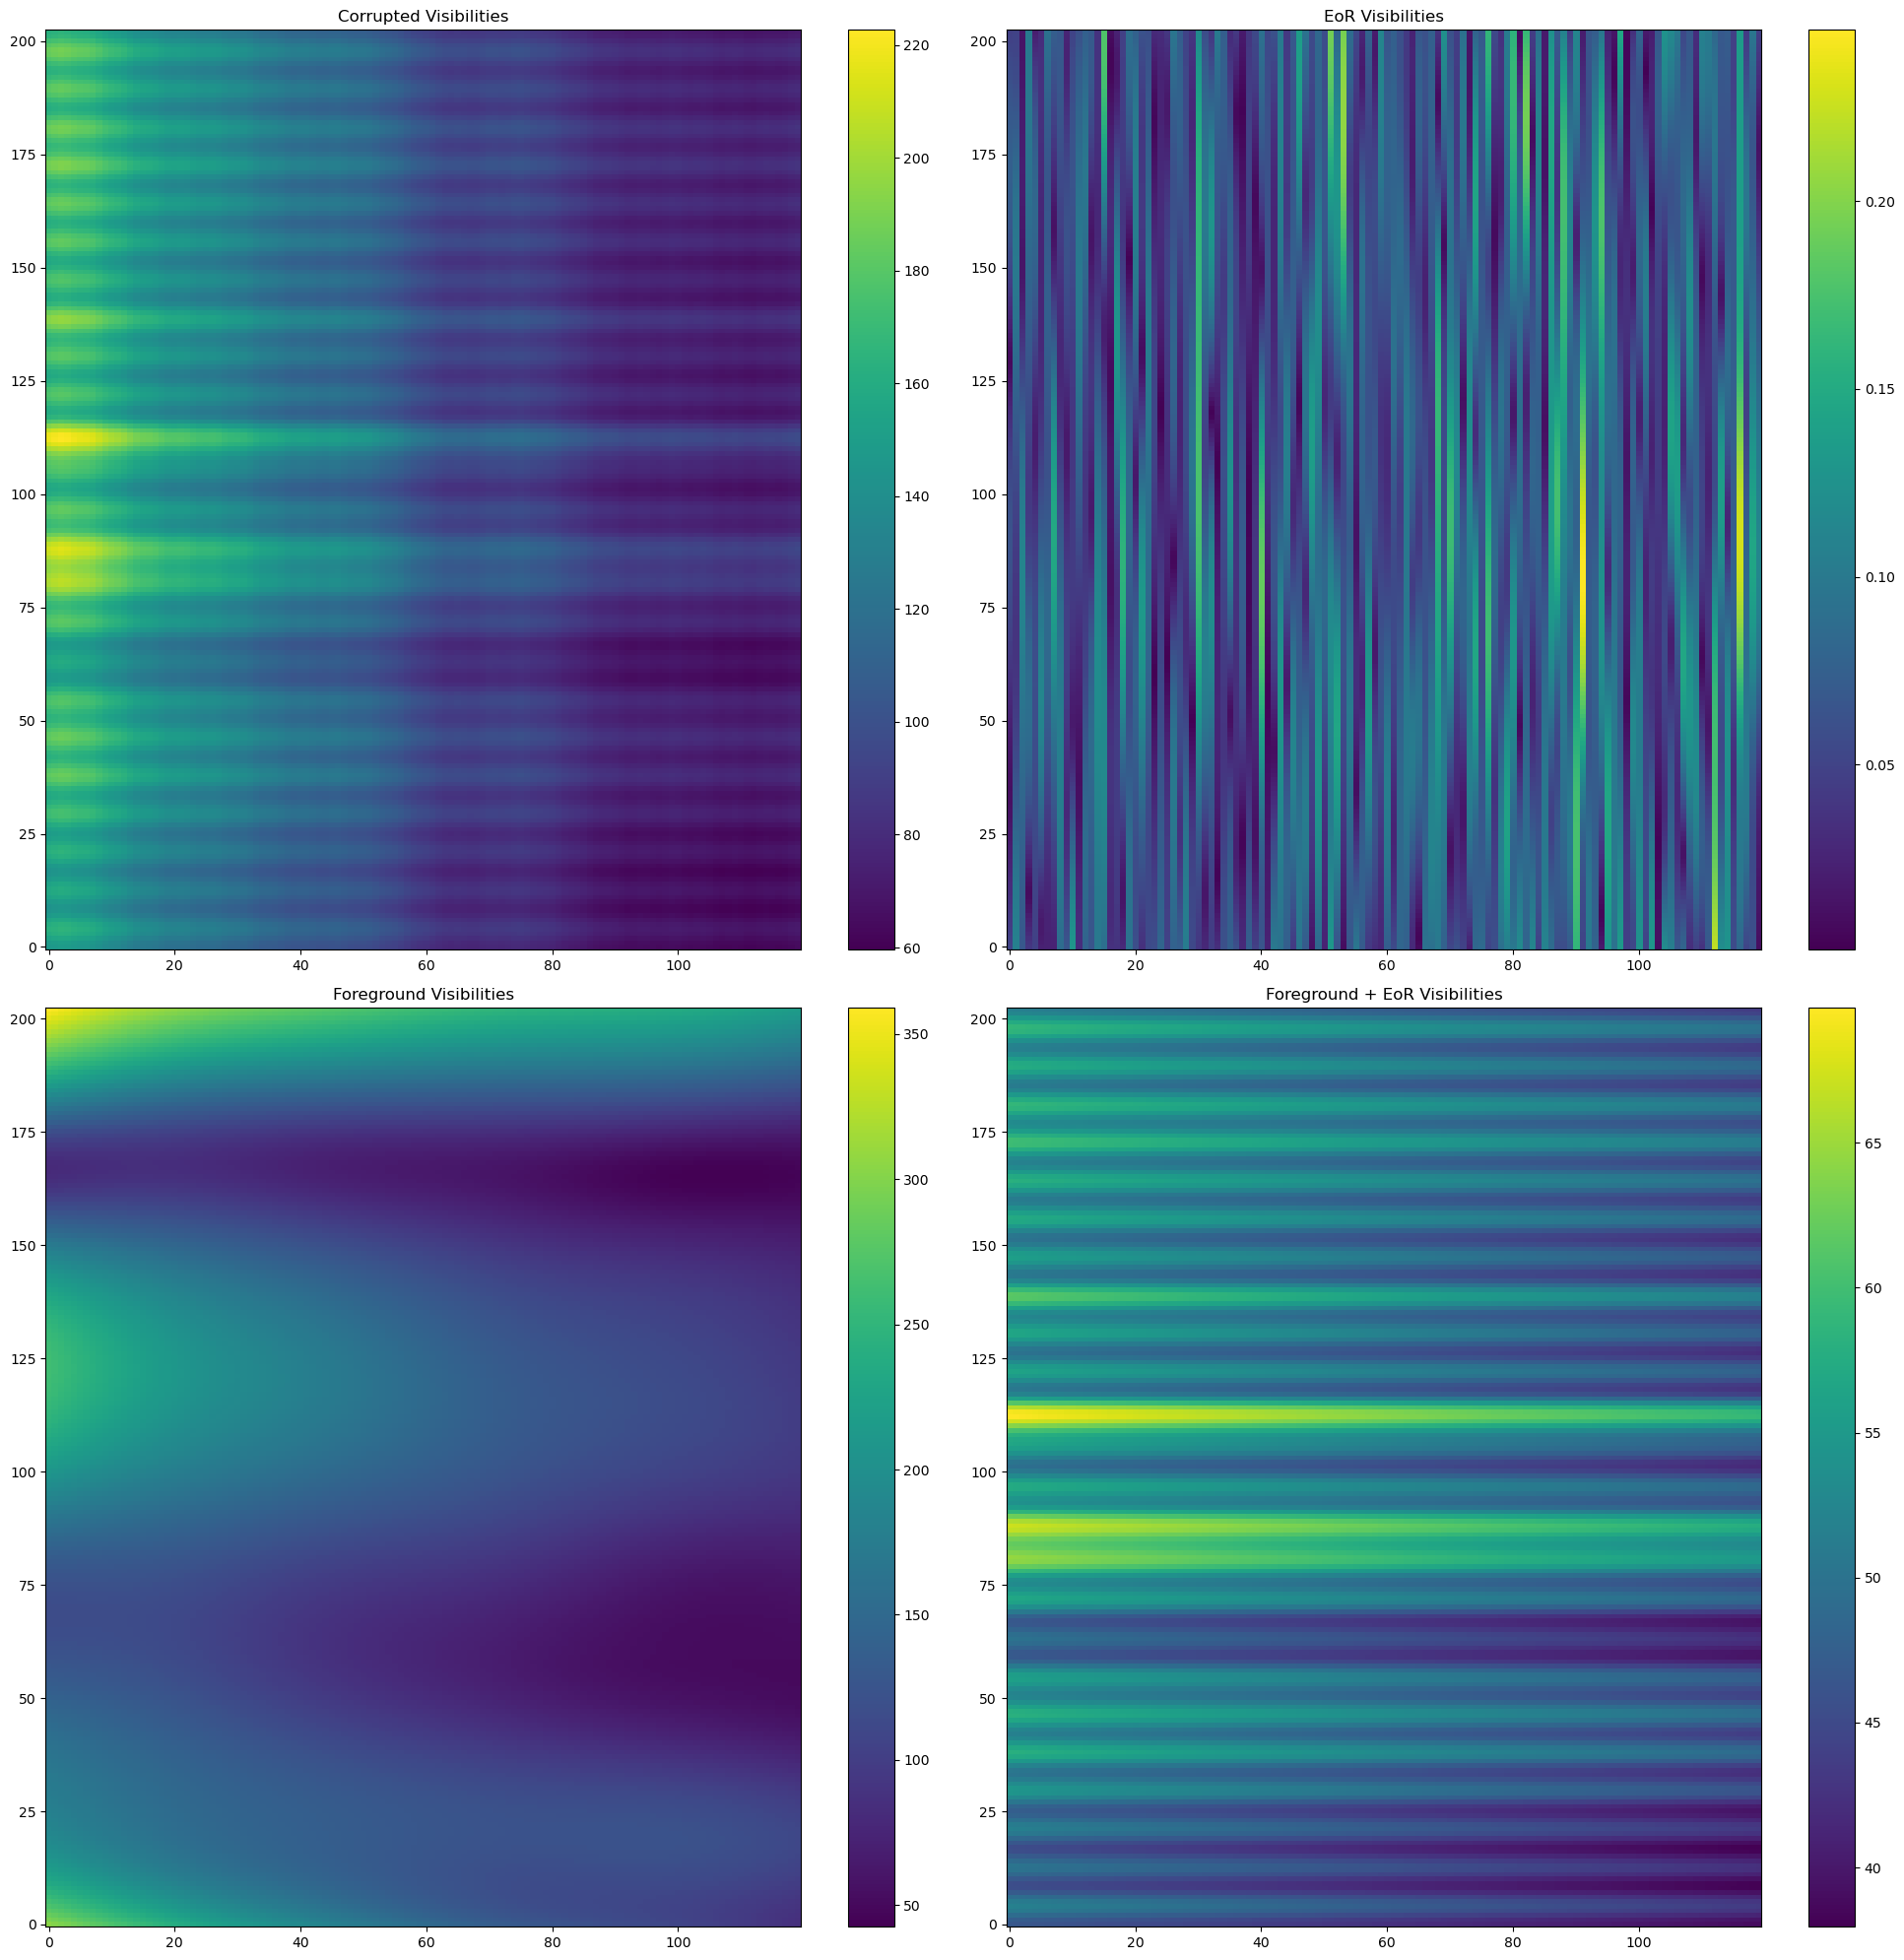

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(20, 20))
im0 = ax[0, 0].imshow(np.abs(vis_corr), aspect='auto', origin='lower')
ax[0, 0].set_title('Corrupted Visibilities')
fig.colorbar(im0, ax=ax[0, 0])
im1 = ax[0, 1].imshow(np.abs(vis_eor), aspect='auto', origin='lower')
ax[0, 1].set_title('EoR Visibilities')
fig.colorbar(im1, ax=ax[0, 1])
im2 = ax[1, 0].imshow(np.abs(vis_fg), aspect='auto', origin='lower')
ax[1, 0].set_title('Foreground Visibilities')
fig.colorbar(im2, ax=ax[1, 0])
im3 = ax[1, 1].imshow(np.abs(vis_fg_eor), aspect='auto', origin='lower')
ax[1, 1].set_title('Foreground + EoR Visibilities')
fig.colorbar(im3, ax=ax[1, 1])
plt.tight_layout()

In [9]:
import sys
sys.path.append('/nvme2/scratch/sohini/plots-hydra-pspec')
from plotting_functions import plot_waterfalls, plot_waterfalls_from_dlfr

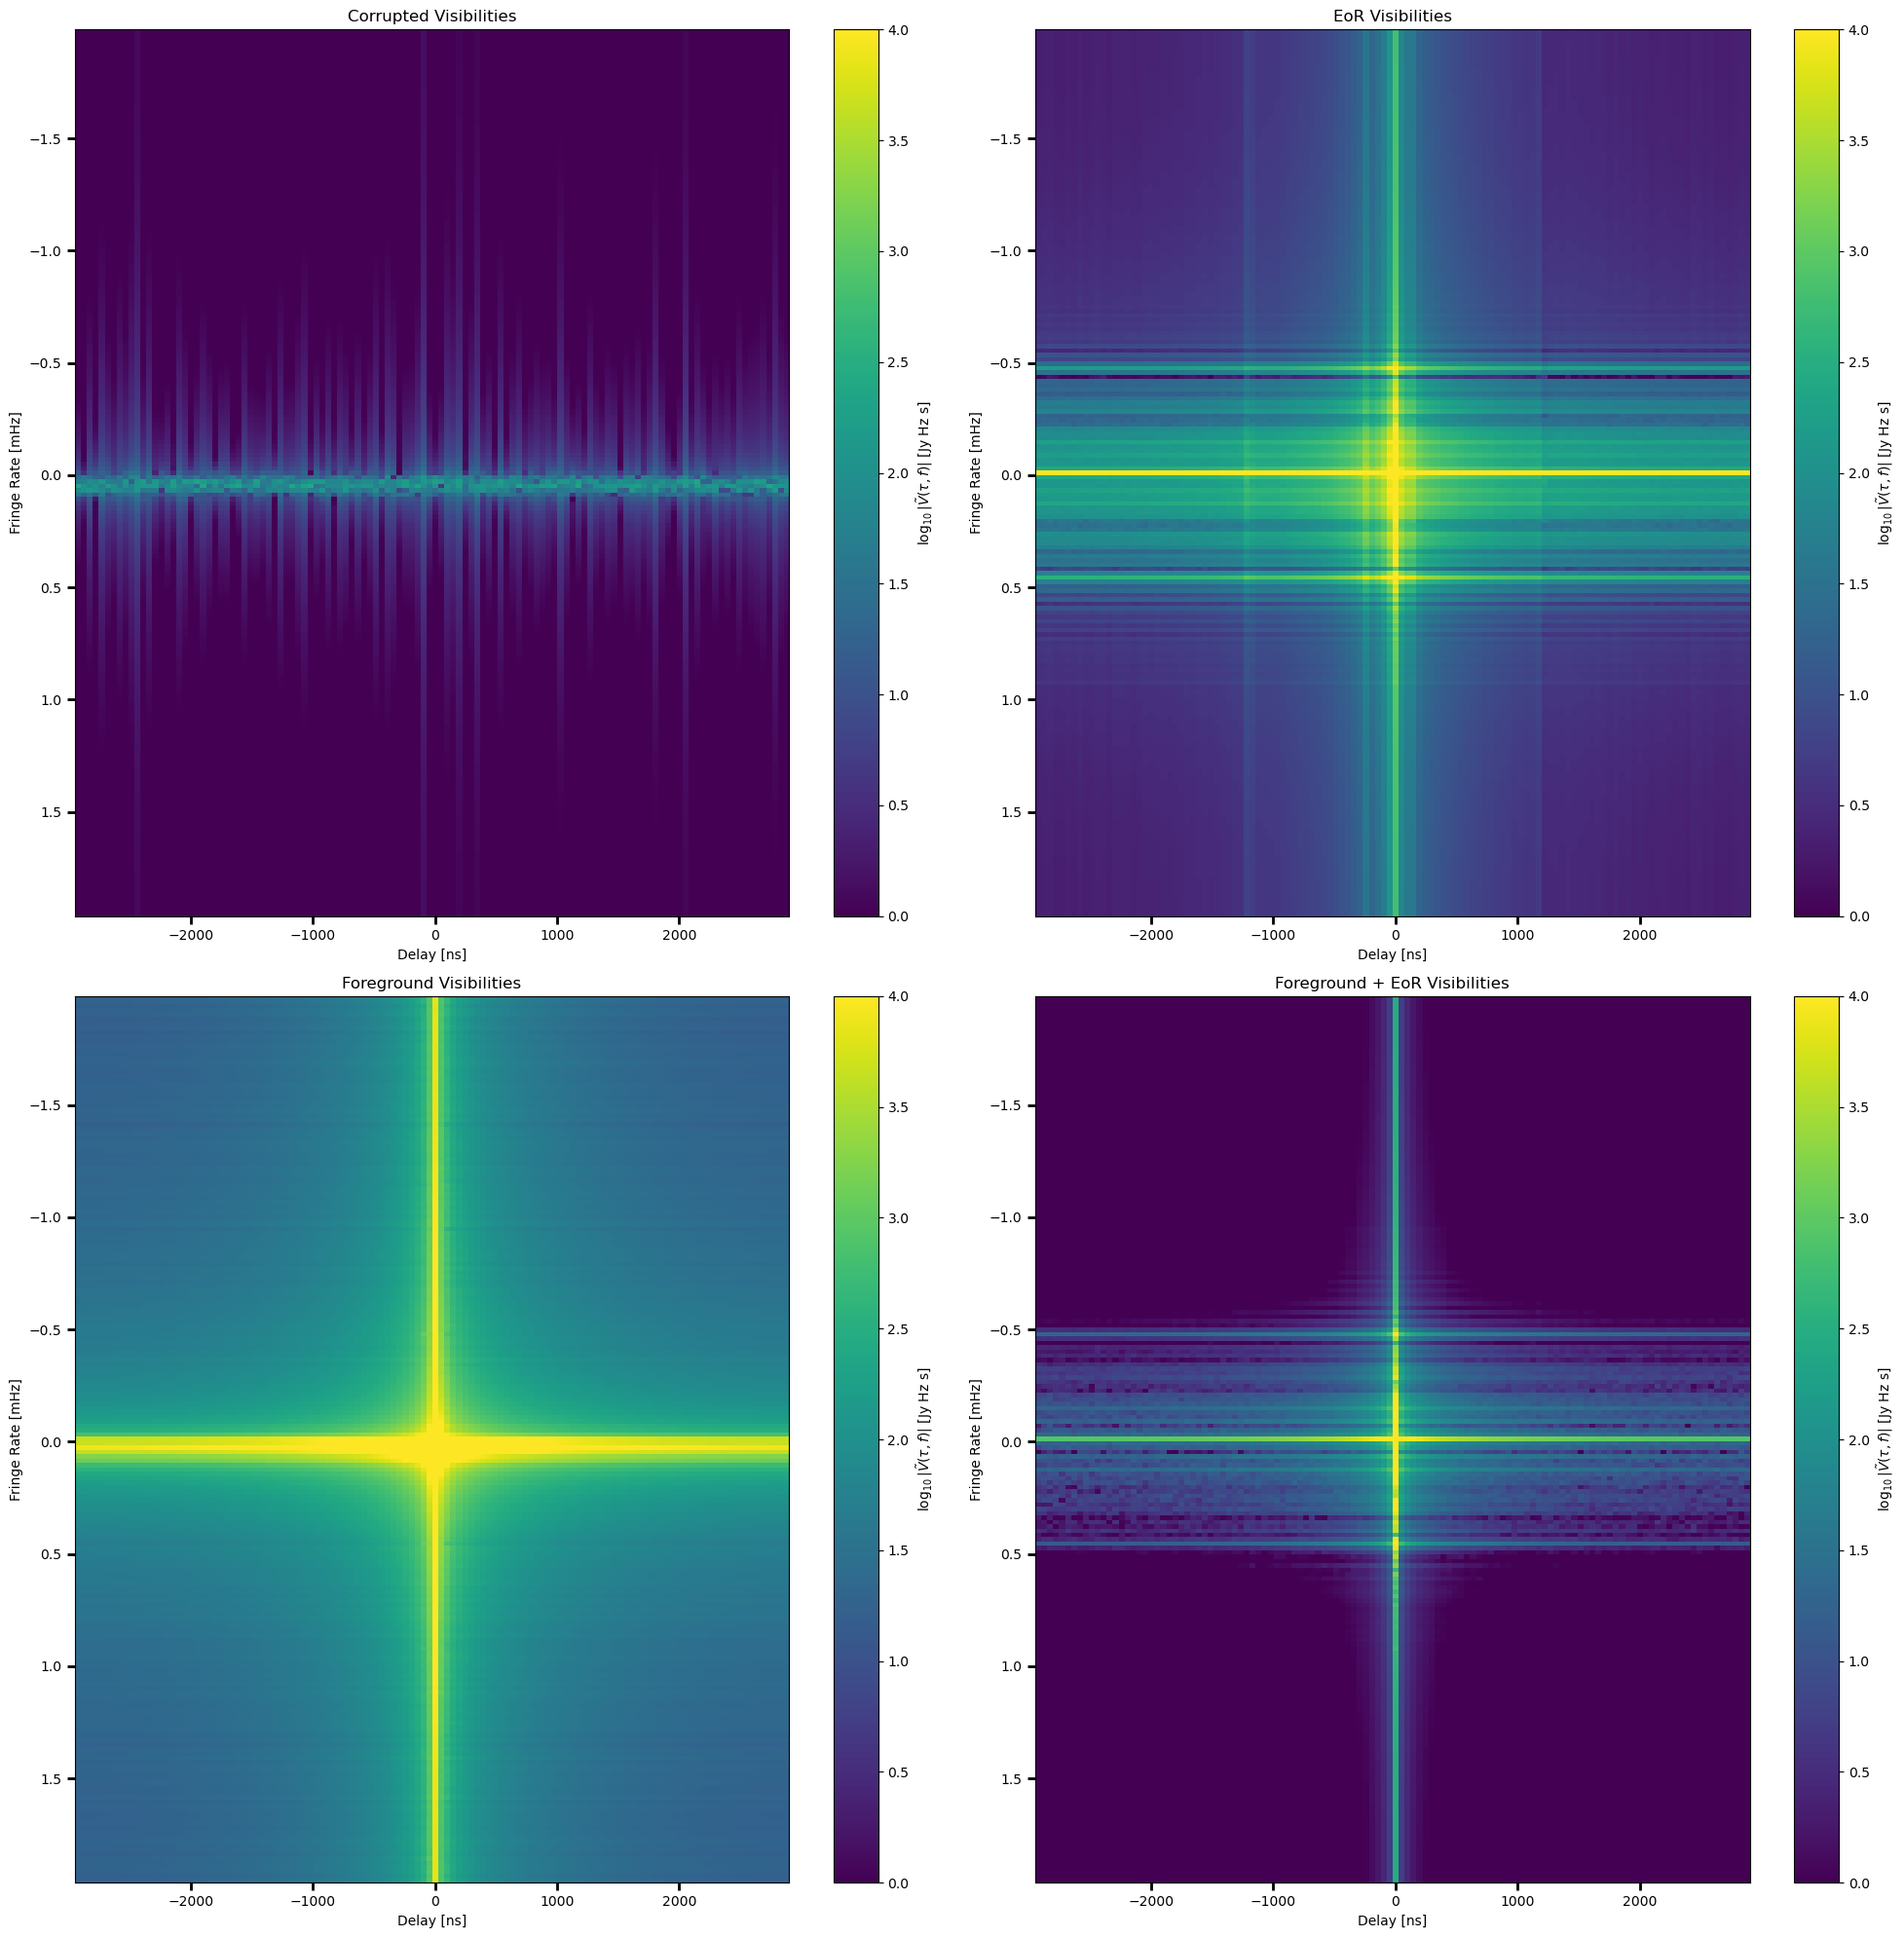

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(20, 20))

im0 = plot_waterfalls(vis_corr, freqs_Hz, lsts_rad, fig=fig, ax=ax[0,1], mode='log',
        vmin=0, vmax=4, cmap='viridis', dynamic_range=5, limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',)
ax[0, 0].set_title('Corrupted Visibilities')
im1 = plot_waterfalls(vis_eor, freqs_Hz, lsts_rad, fig=fig, ax=ax[0,0], mode='log',
        vmin=0, vmax=4, cmap='viridis', dynamic_range=5, limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',)
ax[0, 1].set_title('EoR Visibilities')
im2 = plot_waterfalls(vis_fg, freqs_Hz, lsts_rad, fig=fig, ax=ax[1,0], mode='log',
        vmin=0, vmax=4, cmap='viridis', dynamic_range=5, limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',)
ax[1, 0].set_title('Foreground Visibilities')
im3 = plot_waterfalls(vis_fg_eor, freqs_Hz, lsts_rad, fig=fig, ax=ax[1,1], mode='log',
        vmin=0, vmax=4, cmap='viridis', dynamic_range=5, limit_drng='all', colorbar_flag=True,
        baseline=None, horizon_color='magenta',)
ax[1, 1].set_title('Foreground + EoR Visibilities')
plt.tight_layout()

In [14]:
mask_ind.shape

(2, 61)